In [72]:
import numpy as np
import pandas as pd
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import seaborn as sns

def fit_knn(X_train, y_train):
    return np.array(X_train), np.array(y_train)

In [73]:
def processingdata():
    df = pd.read_csv("../Dataset/healthcare-dataset-stroke-data.csv")
    dictn = {}
    cols = df.select_dtypes(include=["object"]).columns
    for col in df.columns:
        if col in cols:
            df[col] = df[col].fillna(df[col].mode()[0])
            uni_vals = df[col].unique()
            mpp = {val: i for i, val in enumerate(uni_vals)}
            df[col] = df[col].map(mpp)
            dictn[col] = mpp
        else:
            df[col] = pd.to_numeric(df[col], errors="coerce")
            df[col] = df[col].fillna(df[col].mean())
    return df, dictn

In [74]:
def predict_point(x, X_train, y_train, k):
    distances = np.linalg.norm(X_train - x, axis=1)
    k_indices = np.argsort(distances)[:k]
    k_labels = y_train[k_indices]
    label_count = Counter(k_labels)
    return label_count.most_common(1)[0][0]

In [75]:
def predict_proba_point(x, X_train, y_train, k):
    distances = np.linalg.norm(X_train - x, axis=1)
    k_indices = np.argsort(distances)[:k]
    k_labels = y_train[k_indices]
    count = Counter(k_labels)
    prob_1 = count.get(1, 0) / k
    return prob_1

In [76]:
def predict(X_test, X_train, y_train, k):
    return np.array([predict_point(x, X_train, y_train, k) for x in X_test])

def predict_proba(X_test, X_train, y_train, k):
    return np.array([predict_proba_point(x, X_train, y_train, k) for x in X_test])


In [77]:
df, _ = processingdata()
df.drop(columns=["id"], inplace=True, errors="ignore")
X = df.drop("stroke", axis=1)
y = df["stroke"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [78]:
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

# --- Use Basic KNN ---
k = 7
X_train_fit, y_train_fit = fit_knn(X_train_bal, y_train_bal)

# Get prediction probabilities
probs = predict_proba(X_test, X_train_fit, y_train_fit, k)
threshold = 0.35
y_pred = (probs >= threshold).astype(int)


Accuracy: 75.24%

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.76      0.85       972
           1       0.11      0.60      0.19        50

    accuracy                           0.75      1022
   macro avg       0.54      0.68      0.52      1022
weighted avg       0.93      0.75      0.82      1022



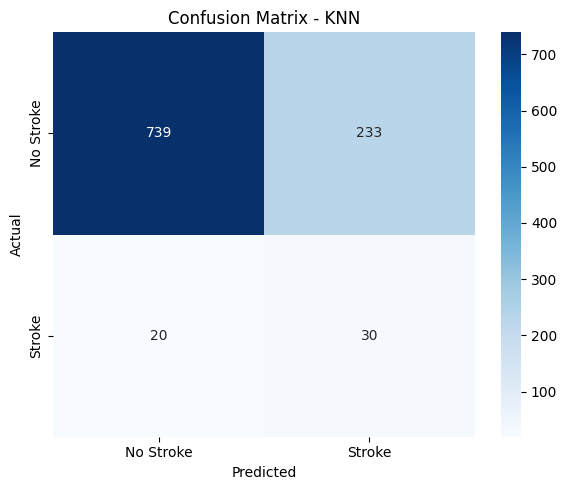

In [79]:
acc = accuracy_score(y_test, y_pred)
print(f"\nAccuracy: {acc*100:.2f}%")

cm = confusion_matrix(y_test, y_pred)

print("\nClassification Report:\n", classification_report(y_test, y_pred))

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Stroke", "Stroke"],
            yticklabels=["No Stroke", "Stroke"])
plt.title("Confusion Matrix - KNN")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()